 # Σύστημα κατηγοριοποίησης κειμένων
 Σκοπός της εργασίας είναι η ανάπτυξη και σύγκριση μοντέλων μηχανικής μάθησης για τον εντοπισμό ανεπιθύμητης αλληλογραφίας (Spam). Θα χρησιμοποιηθούν τεχνικές επεξεργασίας φυσικής γλώσσας (NLP) και αλγόριθμοι ταξινόμησης.


1. Εισαγωγή των απαραίτητων βιβλιοθηκών και εργαλειών για διαχείριση των δεδομένων.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_curve, auc)

pd.set_option('display.max_colwidth', 100)
sns.set(style="whitegrid")

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

2. Φόρτωση Δεδομένων.

In [3]:
file_path = 'emails.csv'

if not os.path.exists(file_path):
    print(f"Το αρχείο {file_path} δεν βρέθηκε!")
else:
    df = pd.read_csv(file_path)
    
    df.dropna(subset=['text', 'spam'], inplace=True)
    
    print(f"Σύνολο εγγραφών: {len(df)}")
    
    display(df.head())

Σύνολο εγγραφών: 5728


,text,spam
0,Subject: naturally irresistible your corporate identity lt is really hard to recollect a compan...,1
1,Subject: the stock trading gunslinger fanny is merrill but muzo not colza attainder and penulti...,1
2,Subject: unbelievable new homes made easy im wanting to show you this homeowner you have been...,1
3,Subject: 4 color printing special request additional information now ! click here click here f...,1
4,"Subject: do not have money , get software cds from here ! software compatibility . . . . ain ' ...",1


3. Ανάλυση & Προεπεξεργασία.

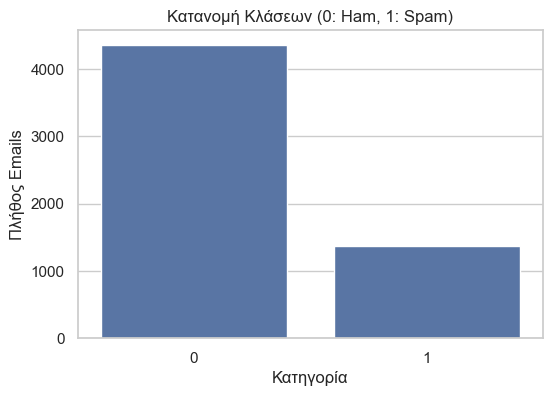

Ham     4360
Spam    1368


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='spam', data=df)
plt.title('Κατανομή Κλάσεων (0: Ham, 1: Spam)')
plt.xlabel('Κατηγορία')
plt.ylabel('Πλήθος Emails')
plt.show()

counts = df['spam'].value_counts()
counts.index = ['Ham', 'Spam']
print(counts.to_string())

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text)
    text = text.replace('Subject:', '')
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

df['cleaned_text'] = df['text'].apply(preprocess_text)
print(df['cleaned_text'].head())

0    naturally irresistible corporate identity lt really hard recollect company market full suqgestio...
1    stock trading gunslinger fanny merrill muzo colza attainder penultimate like esmark perspicuous ...
2    unbelievable new home made easy im wanting show homeowner pre approved home loan fixed rate offe...
3    color printing special request additional information click click printable version order form p...
4    money get software cd software compatibility great grow old along best yet tradgedies finish dea...
Name: cleaned_text, dtype: object


4. Εξαγωγή Χαρακτηριστικών.

In [7]:
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['cleaned_text']).toarray()
y = df['spam'].values

pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_tfidf)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X_pca, y, df.index, test_size=0.2, random_state=42, stratify=y)

print(f"Διαστάσεις Train Set: {X_train.shape}")
print(f"Διαστάσεις Test Set:  {X_test.shape}")

Διαστάσεις Train Set: (4582, 100)
Διαστάσεις Test Set:  (1146, 100)


5. Εκπαίδευση Μοντέλων.

In [8]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


6. Αξιολόγηση Μοντέλων.

Naive Bayes CV:   0.9339
Random Forest CV: 0.9814

>> Classification Report: Naive Bayes
              precision    recall  f1-score   support

         Ham       0.94      0.97      0.95       872
        Spam       0.90      0.79      0.84       274

    accuracy                           0.93      1146
   macro avg       0.92      0.88      0.90      1146
weighted avg       0.93      0.93      0.93      1146



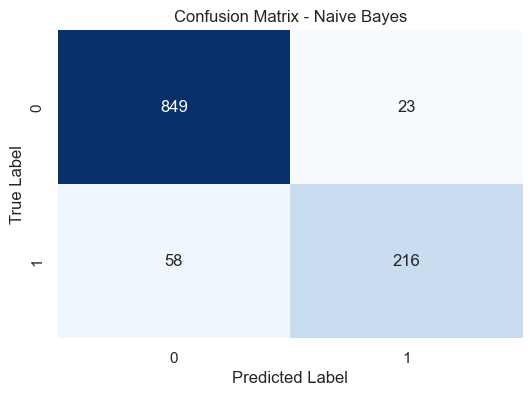


>> Classification Report: Random Forest
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       872
        Spam       0.97      0.97      0.97       274

    accuracy                           0.99      1146
   macro avg       0.98      0.98      0.98      1146
weighted avg       0.99      0.99      0.99      1146



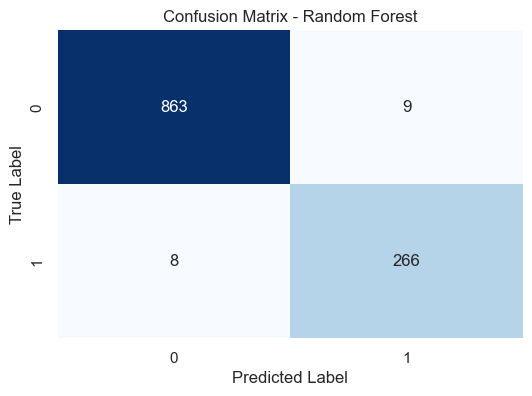

In [9]:
cv_nb = cross_val_score(nb_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Naive Bayes CV:   {cv_nb.mean():.4f}")

cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Random Forest CV: {cv_rf.mean():.4f}")

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f"\n>> Classification Report: {name}")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    return y_pred

nb_pred = evaluate_model(nb_model, X_test, y_test, "Naive Bayes")
rf_pred = evaluate_model(rf_model, X_test, y_test, "Random Forest")

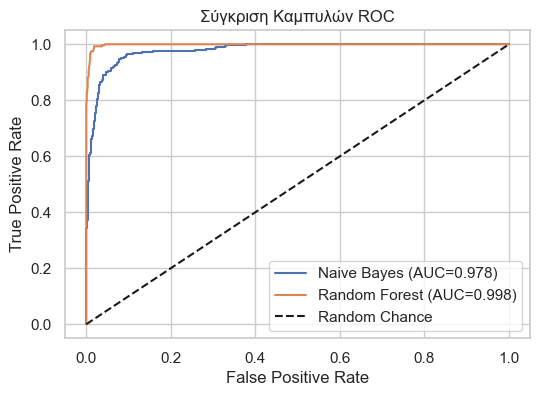

In [10]:
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={auc(fpr_nb, tpr_nb):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc(fpr_rf, tpr_rf):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('Σύγκριση Καμπυλών ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

7. Ανάλυση Σφαλμάτων.

In [12]:
errors_mask = y_test != rf_pred
error_indices = idx_test[errors_mask]

error_df = df.loc[error_indices, ['cleaned_text', 'spam']].copy()
error_df['predicted'] = rf_pred[errors_mask]

error_df.to_csv('model_errors.csv', index=False)

print("\nΔείγμα Λαθών:")
display(error_df.head(5))


Δείγμα Λαθών:


,cleaned_text,spam,predicted
5560,u news archive ft com reliable country intelligence challenging world country report supporting ...,0,1
933,look shop prescription need minute sex last hour great mind think alike fool seldom differ model...,1,0
4455,linux hit miss network world fusion focus phil hochmuth linux today focus linux hit miss corpora...,0,1
1348,hilarious prank call service please visit http ukprankcalls com play hilarious joke mate,1,0
122,help television seat knoweledge chrono cross,1,0
